In [47]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# Configuration
CSV_PATH = "C:\\Users\\Pratik\\Desktop\\CCRAI\\full_image_mask_mapping.csv" # Replace with your actual CSV filename
IMG_SIZE = 256
BATCH_SIZE = 16
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Dataloader 

In [48]:
import pandas as pd
import cv2
import numpy as np
import torch

def get_data_batch(csv_path, num_samples):
    # 1. Load the CSV file
    df = pd.read_csv(csv_path)
    
    # Limit the number of samples as requested
    df = df.head(num_samples)
    
    images = []
    masks = []
    
    for index, row in df.iterrows():
        img_path = row['image_path']
        mask_path = row['mask_path']

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        

        image = image.astype(np.float32) / 255.0
        mask = mask.astype(np.float32) / 255.0
        
        # Append to lists
        images.append(image)
        masks.append(mask)
        
    # 6. Convert lists to NumPy arrays or Tensors
    images = np.array(images)
    masks = np.array(masks)
    
    # Reshape masks to include channel dimension (Batch, H, W, 1)
    masks = np.expand_dims(masks, axis=-1)
    
    return images, masks


In [49]:
# 1. Essential magic command for Jupyter
%matplotlib inline

import pandas as pd
import cv2
import matplotlib.pyplot as plt
import os

def test_single_image(csv_path):
    # Load CSV
    df = pd.read_csv(csv_path)
    
    # Get paths from the first row
    img_path = df.iloc[10000]['image_path']
    mask_path = df.iloc[10000]['mask_path']

    # Print paths to verify they are correct
    print(f"Loading Image: {img_path}")
    print(f"Loading Mask: {mask_path}")

    # Check if files actually exist
    if not os.path.exists(img_path) or not os.path.exists(mask_path):
        print("❌ Error: Files not found! Check your CSV paths.")
        return

    # Read and process
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # Plotting
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    
    ax[0].imshow(img)
    ax[0].set_title("Original Image (JPG)")
    ax[0].axis('off')
    
    ax[1].imshow(mask, cmap='gray')
    ax[1].set_title("Mask (PNG)")
    ax[1].axis('off')
    
    plt.show()

# Run the test
# test_single_image('your_data.csv')

Loading Image: C:\Users\Pratik\Desktop\CCRAI\PlantAI\Indian Medicinal Leaves Image Datasets\Medicinal plant dataset\Honge\227.jpg
Loading Mask: C:\Users\Pratik\Desktop\CCRAI\PlantAI\Medicinal plant masks\Honge\227.png


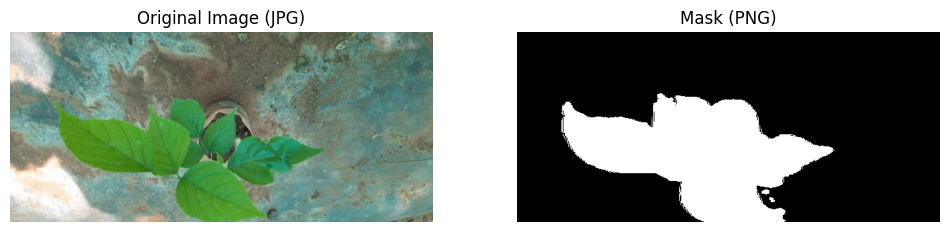

In [50]:
test_single_image('mapping.csv')

In [51]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import cv2
import numpy as np

class SegmentationDataset(Dataset):
    def __init__(self, csv_path):
        self.df = pd.read_csv(csv_path)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Get paths from CSV
        img_path = self.df.iloc[idx]['image_path']
        mask_path = self.df.iloc[idx]['mask_path']

        # Read image and mask from disk
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(f"Image not found: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise FileNotFoundError(f"Mask not found: {mask_path}")
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

        # Normalize to [0, 1]
        image = image.astype(np.float32) / 255.0
        mask = mask.astype(np.float32) / 255.0

        # Change to (Channel, Height, Width) for PyTorch
        image = np.transpose(image, (2, 0, 1))
        mask = np.expand_dims(mask, axis=0)  # Add channel dim: (1, H, W)

        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)

In [52]:
import segmentation_models_pytorch as smp

# Create the model
model = smp.Unet(
    encoder_name="resnet34",        # Choose backbone
    encoder_weights="imagenet",     # Use pre-trained weights
    in_channels=3,                  # RGB images
    classes=1,                      # 1 for binary segmentation (mask)
    activation='sigmoid'            # Output values between 0 and 1
)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [53]:
from tqdm.notebook import tqdm
import torch.optim as optim

# 1. Setup Data
dataset = SegmentationDataset('mapping.csv')
train_loader = DataLoader(dataset, batch_size=8, shuffle=True)

# 2. Setup Loss and Optimizer
criterion = smp.losses.DiceLoss(mode='binary')
optimizer = optim.Adam(model.parameters(), lr=0.0001)

def train_model(epochs):
    for epoch in range(epochs):
        model.train()
        # tqdm creates the progress bar and shows estimation time
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        
        epoch_loss = 0
        for images, masks in progress_bar:
            images, masks = images.to(device), masks.to(device)
            
            # Forward pass
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            # Update the progress bar suffix with current loss
            progress_bar.set_postfix({"Loss": loss.item()})

    print("Training Complete!")

# train_model(epochs=5)

In [54]:
train_model(epochs=50)
torch.save(model, "unet.pth")

Epoch 1/50:   0%|          | 0/1606 [00:00<?, ?it/s]

Epoch 2/50:   0%|          | 0/1606 [00:00<?, ?it/s]

Epoch 3/50:   0%|          | 0/1606 [00:00<?, ?it/s]

Epoch 4/50:   0%|          | 0/1606 [00:00<?, ?it/s]

Epoch 5/50:   0%|          | 0/1606 [00:00<?, ?it/s]

...

Epoch 47/50:   0%|          | 0/1606 [00:00<?, ?it/s]

Epoch 48/50:   0%|          | 0/1606 [00:00<?, ?it/s]

Epoch 49/50:   0%|          | 0/1606 [00:00<?, ?it/s]

Epoch 50/50:   0%|          | 0/1606 [00:00<?, ?it/s]

Training Complete!


## Testing


In [64]:
%matplotlib inline

import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def test_with_black_background(model, image_path, device, threshold=0.5):
    # --- 1. Preprocessing ---
    if not os.path.exists(image_path):
        print(f"❌ Error: File not found at {image_path}")
        return

    # Read image as RGB (uint8 type)
    img_orig = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
    # Resize to 224x224 to match model input
    img_resized = cv2.resize(img_rgb, (224, 224))
    
    # Prepare for model: Normalize and Transpose to (B, C, H, W)
    img_input = img_resized.astype(np.float32) / 255.0
    img_input = np.transpose(img_input, (2, 0, 1))
    img_input = torch.from_numpy(img_input).unsqueeze(0).to(device)

    # --- 2. Model Inference ---
    model.eval()
    with torch.no_grad():
        output = model(img_input)
        # Create binary mask (0s and 1s)
        mask_pred = (output > threshold).cpu().numpy().squeeze()

    # --- 3. Create Black Background Image ---
    # Ensure mask is binary integer (0 or 1)
    mask_binary = mask_pred.astype(np.uint8)
    
    # Crucial Step: Expand dimensions to (224, 224, 1) so it can 
    # multiply across all 3 RGB channels of the image
    mask_expanded = np.expand_dims(mask_binary, axis=-1)

    # Multiply image by mask. 
    # Background pixels become (r*0, g*0, b*0) = Black
    segmented_result = img_resized * mask_expanded

    # --- 4. Visualization ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Original Input
    axes[0].imshow(img_resized)
    axes[0].set_title("Original Input (224x224)")
    axes[0].axis('off')

    # The Mask Used
    axes[1].imshow(mask_binary, cmap='gray')
    axes[1].set_title("Binary Mask Prediction")
    axes[1].axis('off')

    # Final Result (Black Background)
    axes[2].imshow(segmented_result)
    axes[2].set_title("Final Segmented Object")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# --- RUN COMMAND ---
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# test_with_black_background(model, "your_test_image.jpg", device)
# --- HOW TO RUN ---
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# test_and_display(model, "your_image.jpg", device)

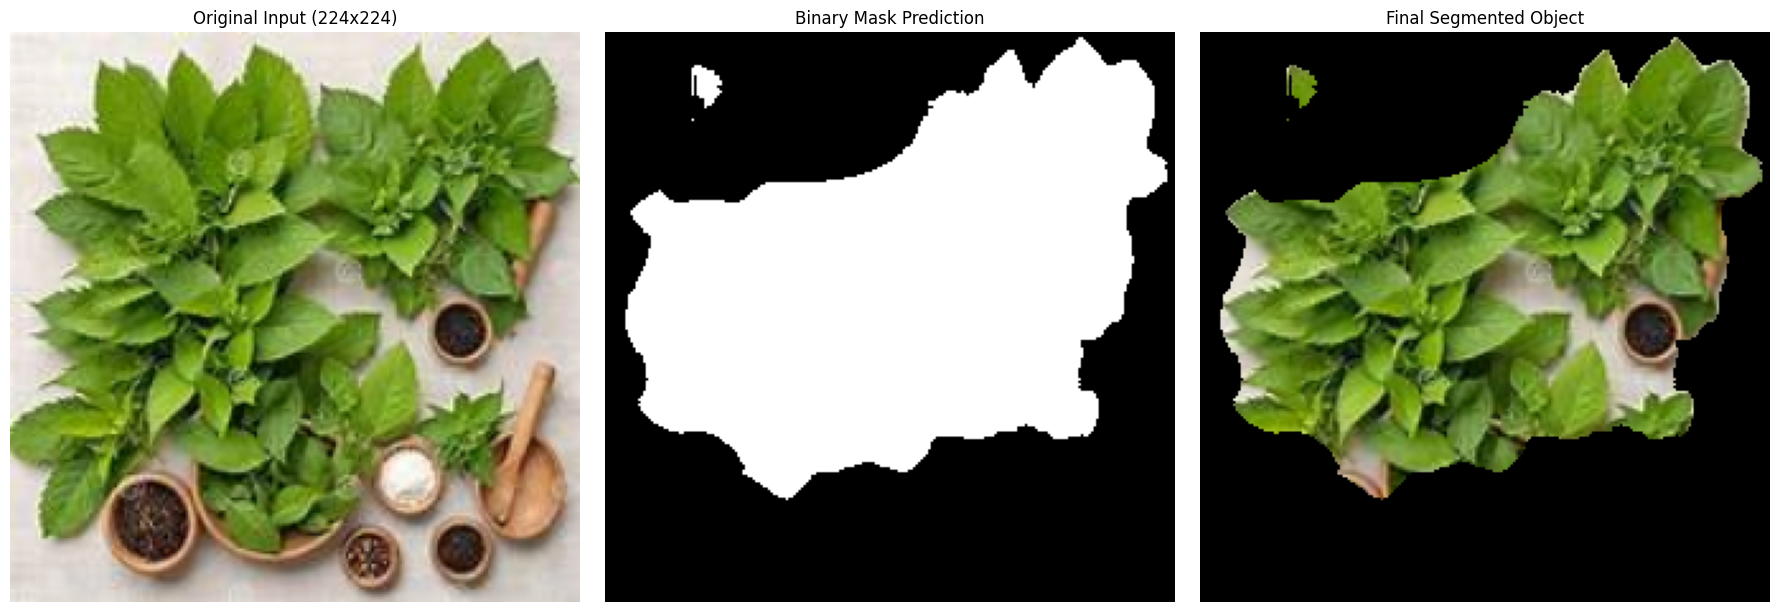

In [68]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_with_black_background(model, r"C:\Users\Pratik\Desktop\CCRAI\Testing\test3.jpeg", device)

In [57]:
import torch
import torchvision.transforms.functional as TF
from PIL import Image
import matplotlib.pyplot as plt

# 1. Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Load the ENTIRE model object
# Replace 'your_full_unet_model.pth' with your actual filename
model_path = r"C:\Users\Pratik\Desktop\CCRAI\PlantAI\segmentation100.pth" 
model = torch.load(model_path, map_location=device)

# 3. Set to evaluation mode and move to GPU
model.to(device)
model.eval()

print(f"Full model loaded successfully on {device}")

Full model loaded successfully on cuda


In [58]:
image_path = r"C:\Users\Pratik\Desktop\CCRAI\PlantAI\test1.jpeg"
test_with_black_background(model, r"C:\Users\Pratik\Desktop\CCRAI\PlantAI\test1.jpeg", device)

❌ Error: File not found at C:\Users\Pratik\Desktop\CCRAI\PlantAI\test1.jpeg


In [59]:
import torch
import cv2
import numpy as np
import os
from pathlib import Path

def process_and_augment_dataset(model, input_root, output_root, device, threshold=0.5):

    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
    model.eval()  # ✅ move outside loop

    for root, _, files in os.walk(input_root):
        for file in files:
            if not file.lower().endswith(valid_extensions):
                continue

            img_path = os.path.join(root, file)
            rel_path = os.path.relpath(root, input_root)
            save_dir = os.path.join(output_root, rel_path)
            os.makedirs(save_dir, exist_ok=True)

            # --- Load image ---
            img_bgr = cv2.imread(img_path)
            if img_bgr is None:
                continue

            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            img_resized = cv2.resize(img_rgb, (224, 224))

            # --- Prepare input ---
            img_input = img_resized.astype(np.float32) / 255.0
            img_input = np.transpose(img_input, (2, 0, 1))  # HWC → CHW
            img_input = torch.tensor(img_input).unsqueeze(0).to(device)

            # --- Inference ---
            with torch.no_grad():
                output = model(img_input)

                # ✅ Apply sigmoid
                output = torch.sigmoid(output)

                # Shape: (1, 1, H, W) → (H, W)
                mask = (output > threshold).float()
                mask = mask.squeeze().cpu().numpy()

            # --- Apply mask ---
            mask_3c = np.repeat(mask[:, :, None], 3, axis=2)
            segmented = (img_resized * mask_3c).astype(np.uint8)
            segmented_bgr = cv2.cvtColor(segmented, cv2.COLOR_RGB2BGR)

            base_name = Path(file).stem

            # A. Original segmented
            cv2.imwrite(os.path.join(save_dir, f"{base_name}_seg.jpg"), segmented_bgr)

            # B. Rotated
            rotated = cv2.rotate(segmented_bgr, cv2.ROTATE_90_CLOCKWISE)
            cv2.imwrite(os.path.join(save_dir, f"{base_name}_rot90.jpg"), rotated)

            # C. Contrast enhanced
            contrast = cv2.convertScaleAbs(segmented_bgr, alpha=1.5, beta=0)
            cv2.imwrite(os.path.join(save_dir, f"{base_name}_contrast.jpg"), contrast)

    print(f"✅ Dataset processing complete. Saved to: {output_root}")


In [60]:
process_and_augment_dataset(model, 
                            r"C:\Users\Pratik\Desktop\CCRAI\PlantAI\Indian Medicinal Leaves Image Datasets\Medicinal Leaf dataset",
                            "final dataset",
                            device)

✅ Dataset processing complete. Saved to: final dataset
